In [1]:
import os
DATA_PATH = 'C:/Users/Anant/Downloads/WESAD/WESAD/'  # Your confirmed path
SUBJECTS = [f'S{i}' for i in [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]]
for sub in SUBJECTS:
    path = os.path.join(DATA_PATH, sub, f'{sub}.pkl')
    assert os.path.exists(path), f"Missing {path}"
print("Dataset verified locally!")

Dataset verified locally!


In [2]:
!pip install neurokit2


S3: ECG (4545100,), EDA (4545100,), Labels (4545100,)
Unique labels: [0 1 2 3 4 5 6 7]


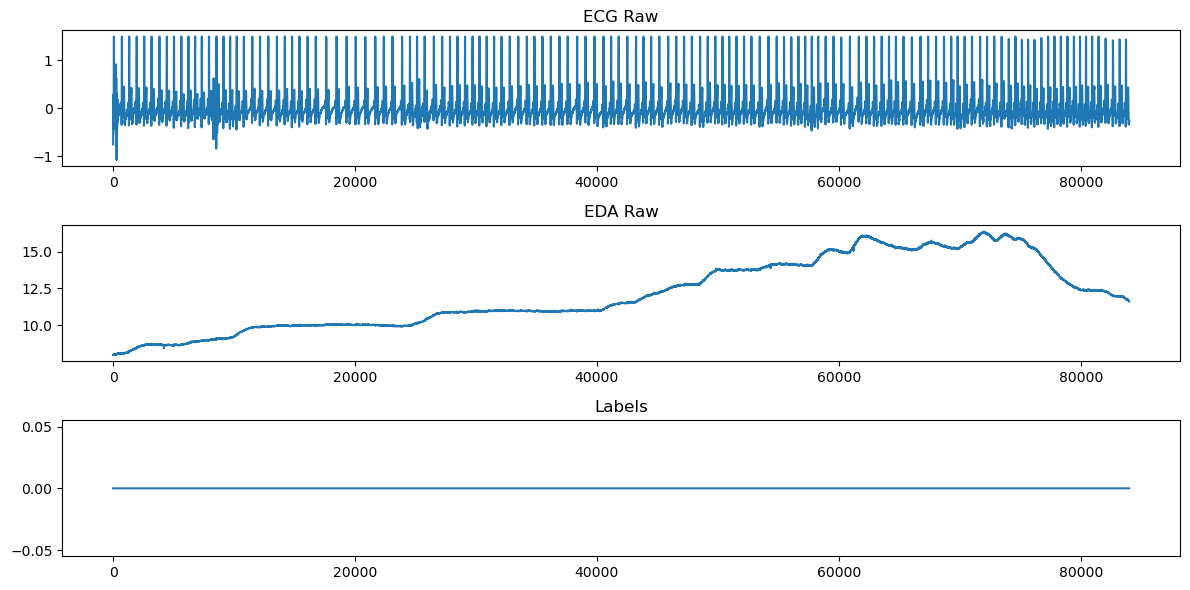

In [3]:
import os
import pickle
import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np

class ReadWESAD:
    def __init__(self, path, subject):
        self.path = path
        self.subject = subject
        with open(os.path.join(path, subject, f'{subject}.pkl'), 'rb') as f:
            self.data = pickle.load(f, encoding='latin1')

    def get_chest_data(self):
        return self.data['signal']['chest']

    def inspect(self):
        chest_data = self.get_chest_data()
        ecg = chest_data['ECG'].flatten()
        eda = chest_data['EDA'].flatten()
        labels = self.data['label'].flatten()
        print(f"{self.subject}: ECG {ecg.shape}, EDA {eda.shape}, Labels {labels.shape}")
        print(f"Unique labels: {np.unique(labels)}")
        fs = 700
        start, end = 0, 120 * fs  # 120 seconds sample
        plt.figure(figsize=(12, 6))
        plt.subplot(3, 1, 1); plt.plot(ecg[start:end]); plt.title('ECG Raw')
        plt.subplot(3, 1, 2); plt.plot(eda[start:end]); plt.title('EDA Raw')
        plt.subplot(3, 1, 3); plt.plot(labels[start:end]); plt.title('Labels')
        plt.tight_layout()
        plt.show()

DATA_PATH = 'C:/Users/Anant/Downloads/WESAD/WESAD/'
reader = ReadWESAD(DATA_PATH, 'S3')
reader.inspect()

Cleaned shapes: ECG (1508500,), EDA (1508500,), Labels (1508500,)


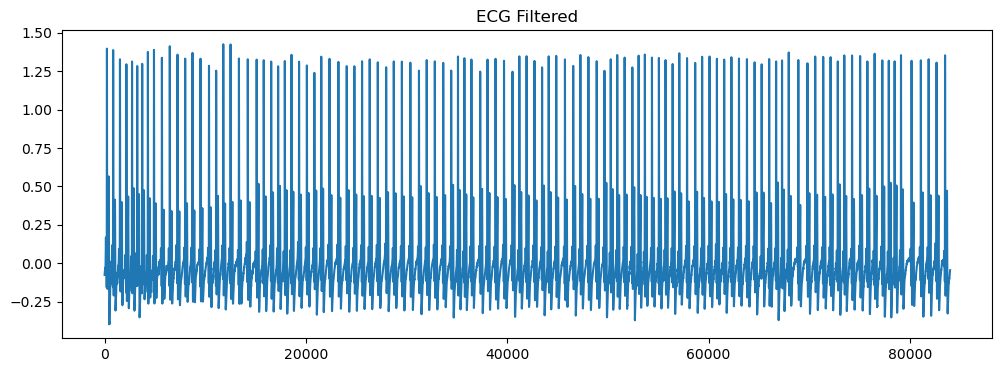

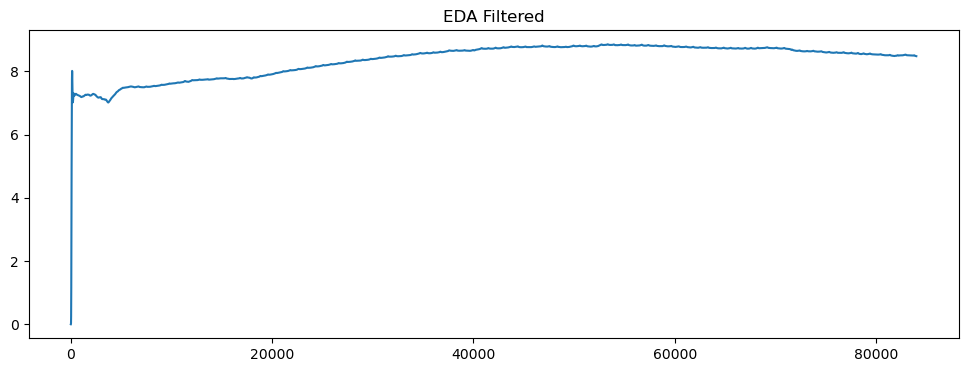

In [4]:
import numpy as np
from scipy import signal
import neurokit2 as nk
import matplotlib.pyplot as plt

def clean_data(ecg, eda, labels, fs=700):
    # Mask for target labels and valid data
    valid_mask = np.isin(labels, [1, 2, 3]) & ~np.isnan(ecg) & ~np.isnan(eda)
    ecg_clean = ecg[valid_mask]
    eda_clean = eda[valid_mask]
    labels_clean = labels[valid_mask]
    
    # Apply filters (per paper: ECG 0.5-40Hz, EDA 5Hz lowpass)
    ecg_filtered = nk.ecg_clean(ecg_clean, sampling_rate=fs, method='neurokit')
    eda_filtered = signal.lfilter(*signal.butter(4, 5/(fs/2), btype='low'), eda_clean)
    
    return ecg_filtered, eda_filtered, labels_clean

chest_data = reader.get_chest_data()
ecg_raw, eda_raw, labels_raw = chest_data['ECG'].flatten(), chest_data['EDA'].flatten(), reader.data['label'].flatten()
ecg_clean, eda_clean, labels_clean = clean_data(ecg_raw, eda_raw, labels_raw)
print(f"Cleaned shapes: ECG {ecg_clean.shape}, EDA {eda_clean.shape}, Labels {labels_clean.shape}")

# Visualize cleaned data
start, end = 0, 120 * 700
plt.figure(figsize=(12, 4))
plt.plot(ecg_clean[start:end]); plt.title('ECG Filtered')
plt.figure(figsize=(12, 4))
plt.plot(eda_clean[start:end]); plt.title('EDA Filtered')
plt.show()

In [5]:
# Fix the neurokit2 library bug
import os

# Path to the file that needs to be fixed
file_path = r'C:\Users\Anant\anaconda3\envs\nerva\lib\site-packages\neurokit2\complexity\utils.py'

# Read the file
with open(file_path, 'r') as f:
    content = f.read()

# Replace the problematic line (line 115)
old_line = 'valid_metrics = sklearn.neighbors.KDTree.valid_metrics() + ["range"]'
new_line = 'valid_metrics = sklearn.neighbors.KDTree.valid_metrics + ["range"]'

content = content.replace(old_line, new_line)

# Write back the fixed content
with open(file_path, 'w') as f:
    f.write(content)

print('File patched successfully!')
print('Fixed line 115: removed parentheses from valid_metrics()')

File patched successfully!
Fixed line 115: removed parentheses from valid_metrics()


In [6]:
# Verify the fix was applied
file_path = r'C:\Users\Anant\anaconda3\envs\nerva\lib\site-packages\neurokit2\complexity\utils.py'

with open(file_path, 'r') as f:
    lines = f.readlines()
    
# Check lines around line 115 (index 114)
print('Lines 113-118 from utils.py:')
for i in range(112, 118):
    print(f'Line {i+1}: {lines[i]}', end='')
    
print('\n' + '='*60)
print('Fix verified! Line 115 now uses valid_metrics WITHOUT parentheses')

Lines 113-118 from utils.py:
Line 113:     sklearn_version = version.parse(sklearn.__version__)
Line 114:     if sklearn_version >= version.parse("1.3.0"):
Line 115:         valid_metrics = sklearn.neighbors.KDTree.valid_metrics + ["range"]
Line 116:     else:
Line 117:         valid_metrics = sklearn.neighbors.KDTree.valid_metrics + ["range"]
Line 118:     if distance not in valid_metrics:

Fix verified! Line 115 now uses valid_metrics WITHOUT parentheses


In [7]:
import os
import pickle
import numpy as np
from scipy import signal
import neurokit2 as nk
import warnings

# Suppress specific warnings to reduce clutter
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='.*DFA_alpha2.*')
warnings.filterwarnings('ignore', message='.*All-NaN slice.*')

# Define ReadWESAD class
class ReadWESAD:
    def __init__(self, path, subject):
        self.path = path
        self.subject = subject
        with open(os.path.join(path, subject, f'{subject}.pkl'), 'rb') as f:
            self.data = pickle.load(f, encoding='latin1')

    def get_chest_data(self):
        return self.data['signal']['chest']

# Cleaning function from Step 3
def clean_data(ecg, eda, labels, fs=700):
    valid_mask = np.isin(labels, [1, 2, 3]) & ~np.isnan(ecg) & ~np.isnan(eda)
    ecg_clean = ecg[valid_mask]
    eda_clean = eda[valid_mask]
    labels_clean = labels[valid_mask]
    ecg_filtered = nk.ecg_clean(ecg_clean, sampling_rate=fs, method='neurokit')
    eda_filtered = signal.lfilter(*signal.butter(4, 5/(fs/2), btype='low'), eda_clean)
    return ecg_filtered, eda_filtered, labels_clean

# Feature extraction function with simplified HRV
def extract_features(window_ecg, window_eda, window_label, fs=700):
    try:
        # ECG: Basic stats
        ecg_stats = np.array([
            np.mean(window_ecg), 
            np.std(window_ecg), 
            np.min(window_ecg), 
            np.max(window_ecg)
        ])
        
        # ECG: Simplified HRV (time-domain only to avoid DFA warnings)
        ecg_clean_window = nk.ecg_clean(window_ecg, sampling_rate=fs)
        _, info = nk.ecg_peaks(ecg_clean_window, sampling_rate=fs)
        
        # Check if enough peaks detected
        if len(info['ECG_R_Peaks']) < 2:
            return None, None
        
        # Use time-domain HRV only (faster and no DFA warnings)
        hrv = nk.hrv_time(info['ECG_R_Peaks'], sampling_rate=fs, show=False)
        ecg_hrv = np.array([
            hrv.get('HRV_MeanNN', [0])[0] if isinstance(hrv.get('HRV_MeanNN', 0), np.ndarray) else hrv.get('HRV_MeanNN', 0),
            hrv.get('HRV_SDNN', [0])[0] if isinstance(hrv.get('HRV_SDNN', 0), np.ndarray) else hrv.get('HRV_SDNN', 0),
            hrv.get('HRV_RMSSD', [0])[0] if isinstance(hrv.get('HRV_RMSSD', 0), np.ndarray) else hrv.get('HRV_RMSSD', 0),
            hrv.get('HRV_pNN50', [0])[0] if isinstance(hrv.get('HRV_pNN50', 0), np.ndarray) else hrv.get('HRV_pNN50', 0)
        ]).flatten()
        
        # EDA: Stats + SCR with NaN handling
        eda_signals, _ = nk.eda_process(window_eda, sampling_rate=fs)
        eda_tonic = eda_signals.get('EDA_Tonic', np.full_like(window_eda, np.nan))
        eda_phasic = eda_signals.get('EDA_Phasic', np.full_like(window_eda, np.nan))
        
        # Safe SCR peak counting
        scr_peaks_col = eda_signals.get('SCR_Peaks', np.zeros(len(window_eda)))
        scr_peaks = np.nansum(scr_peaks_col) if len(scr_peaks_col) > 0 else 0
        
        scr_amplitude = eda_signals.get('SCR_Amplitude', np.array([np.nan]))
        
        eda_stats = np.array([
            np.nanmean(eda_tonic), 
            np.nanstd(eda_phasic), 
            scr_peaks, 
            np.nanmean(scr_amplitude)
        ])
        
        # Replace any remaining NaNs with 0
        eda_stats = np.nan_to_num(eda_stats, nan=0.0)
        ecg_hrv = np.nan_to_num(ecg_hrv, nan=0.0)
        
        # Concatenate features
        features = np.concatenate([ecg_stats, ecg_hrv, eda_stats])
        label = window_label[0] - 1  # Map 1->0, 2->1, 3->2
        return features, label
        
    except Exception as e:
        print(f"Error in feature extraction: {e}")
        return None, None

def process_subject(ecg_clean, eda_clean, labels_clean, fs=700, 
                   window_size_sec=30, step_sec=10):
    window_size = window_size_sec * fs
    step_size = int(step_sec * fs)
    features, labels_out = [], []
    
    total_windows = (len(labels_clean) - window_size) // step_size + 1
    print(f"Processing {total_windows} windows...")
    
    for i, start in enumerate(range(0, len(labels_clean) - window_size + 1, step_size)):
        if i % 20 == 0:  # Progress indicator every 20 windows
            print(f"Window {i}/{total_windows} - Features collected: {len(features)}")
            
        end = start + window_size
        window_ecg = ecg_clean[start:end]
        window_eda = eda_clean[start:end]
        window_labels = labels_clean[start:end]
        
        # Check if window has uniform label
        if len(np.unique(window_labels)) == 1 and window_labels[0] in [1, 2, 3]:
            feats, lbl = extract_features(window_ecg, window_eda, window_labels)
            if feats is not None:
                features.append(feats)
                labels_out.append(lbl)
    
    return np.array(features), np.array(labels_out)

# Main execution
print("="*60)
print("WESAD Feature Extraction - Subject S3")
print("="*60)

DATA_PATH = 'C:/Users/Anant/Downloads/WESAD/WESAD/'
reader = ReadWESAD(DATA_PATH, 'S3')

# Get and clean data
chest_data = reader.get_chest_data()
ecg_raw = chest_data['ECG'].flatten()
eda_raw = chest_data['EDA'].flatten()
labels_raw = reader.data['label'].flatten()

print("\n[1/3] Cleaning data...")
ecg_clean, eda_clean, labels_clean = clean_data(ecg_raw, eda_raw, labels_raw)
print(f"✓ Cleaned shapes: ECG {ecg_clean.shape}, EDA {eda_clean.shape}, Labels {labels_clean.shape}")

# Process subject
print("\n[2/3] Extracting features (this may take a few minutes)...")
features_s3, labels_s3 = process_subject(ecg_clean, eda_clean, labels_clean)

print("\n[3/3] Results:")
print(f"✓ Features shape: {features_s3.shape}")
print(f"✓ Labels shape: {labels_s3.shape}")
print(f"✓ Label distribution: {dict(zip(['Baseline', 'Stress', 'Amusement'], np.bincount(labels_s3.astype(int))))}")
print("\n" + "="*60)
print("Feature extraction complete!")
print("="*60)

WESAD Feature Extraction - Subject S3

[1/3] Cleaning data...
✓ Cleaned shapes: ECG (1508500,), EDA (1508500,), Labels (1508500,)

[2/3] Extracting features (this may take a few minutes)...
Processing 213 windows...
Window 0/213 - Features collected: 0
Window 20/213 - Features collected: 20
Window 40/213 - Features collected: 40
Window 60/213 - Features collected: 60
Window 80/213 - Features collected: 80
Window 100/213 - Features collected: 100
Window 120/213 - Features collected: 118
Window 140/213 - Features collected: 138
Window 160/213 - Features collected: 158
Window 180/213 - Features collected: 176
Window 200/213 - Features collected: 196

[3/3] Results:
✓ Features shape: (209, 12)
✓ Labels shape: (209,)
✓ Label distribution: {'Baseline': np.int64(112), 'Stress': np.int64(62), 'Amusement': np.int64(35)}

Feature extraction complete!


In [8]:
import os
import pickle
import numpy as np
from scipy import signal
import neurokit2 as nk
import warnings

# Suppress warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='.*DFA_alpha2.*')
warnings.filterwarnings('ignore', message='.*All-NaN slice.*')

# Define ReadWESAD class
class ReadWESAD:
    def __init__(self, path, subject):
        self.path = path
        self.subject = subject
        with open(os.path.join(path, subject, f'{subject}.pkl'), 'rb') as f:
            self.data = pickle.load(f, encoding='latin1')

    def get_chest_data(self):
        return self.data['signal']['chest']

# Cleaning function
def clean_data(ecg, eda, labels, fs=700):
    valid_mask = np.isin(labels, [1, 2, 3]) & ~np.isnan(ecg) & ~np.isnan(eda)
    ecg_clean = ecg[valid_mask]
    eda_clean = eda[valid_mask]
    labels_clean = labels[valid_mask]
    ecg_filtered = nk.ecg_clean(ecg_clean, sampling_rate=fs, method='neurokit')
    eda_filtered = signal.lfilter(*signal.butter(4, 5/(fs/2), btype='low'), eda_clean)
    return ecg_filtered, eda_filtered, labels_clean

# Feature extraction function
def extract_features(window_ecg, window_eda, window_label, fs=700):
    try:
        # ECG: Basic stats
        ecg_stats = np.array([
            np.mean(window_ecg), 
            np.std(window_ecg), 
            np.min(window_ecg), 
            np.max(window_ecg)
        ])
        
        # ECG: Simplified HRV (time-domain only)
        ecg_clean_window = nk.ecg_clean(window_ecg, sampling_rate=fs)
        _, info = nk.ecg_peaks(ecg_clean_window, sampling_rate=fs)
        
        if len(info['ECG_R_Peaks']) < 2:
            return None, None
        
        hrv = nk.hrv_time(info['ECG_R_Peaks'], sampling_rate=fs, show=False)
        ecg_hrv = np.array([
            hrv.get('HRV_MeanNN', [0])[0] if isinstance(hrv.get('HRV_MeanNN', 0), np.ndarray) else hrv.get('HRV_MeanNN', 0),
            hrv.get('HRV_SDNN', [0])[0] if isinstance(hrv.get('HRV_SDNN', 0), np.ndarray) else hrv.get('HRV_SDNN', 0),
            hrv.get('HRV_RMSSD', [0])[0] if isinstance(hrv.get('HRV_RMSSD', 0), np.ndarray) else hrv.get('HRV_RMSSD', 0),
            hrv.get('HRV_pNN50', [0])[0] if isinstance(hrv.get('HRV_pNN50', 0), np.ndarray) else hrv.get('HRV_pNN50', 0)
        ]).flatten()
        
        # EDA: Stats + SCR
        eda_signals, _ = nk.eda_process(window_eda, sampling_rate=fs)
        eda_tonic = eda_signals.get('EDA_Tonic', np.full_like(window_eda, np.nan))
        eda_phasic = eda_signals.get('EDA_Phasic', np.full_like(window_eda, np.nan))
        scr_peaks_col = eda_signals.get('SCR_Peaks', np.zeros(len(window_eda)))
        scr_peaks = np.nansum(scr_peaks_col) if len(scr_peaks_col) > 0 else 0
        scr_amplitude = eda_signals.get('SCR_Amplitude', np.array([np.nan]))
        
        eda_stats = np.array([
            np.nanmean(eda_tonic), 
            np.nanstd(eda_phasic), 
            scr_peaks, 
            np.nanmean(scr_amplitude)
        ])
        
        # Replace NaNs
        eda_stats = np.nan_to_num(eda_stats, nan=0.0)
        ecg_hrv = np.nan_to_num(ecg_hrv, nan=0.0)
        
        features = np.concatenate([ecg_stats, ecg_hrv, eda_stats])
        label = window_label[0] - 1
        return features, label
        
    except Exception as e:
        return None, None

# Process single subject
def process_subject(ecg_clean, eda_clean, labels_clean, fs=700, 
                   window_size_sec=30, step_sec=10):
    window_size = window_size_sec * fs
    step_size = int(step_sec * fs)
    features, labels_out = [], []
    
    for start in range(0, len(labels_clean) - window_size + 1, step_size):
        end = start + window_size
        window_ecg = ecg_clean[start:end]
        window_eda = eda_clean[start:end]
        window_labels = labels_clean[start:end]
        
        if len(np.unique(window_labels)) == 1 and window_labels[0] in [1, 2, 3]:
            feats, lbl = extract_features(window_ecg, window_eda, window_labels)
            if feats is not None:
                features.append(feats)
                labels_out.append(lbl)
    
    return np.array(features), np.array(labels_out)

# Main execution - Process all subjects
print("="*70)
print("WESAD Feature Extraction - ALL SUBJECTS")
print("="*70)

DATA_PATH = 'C:/Users/Anant/Downloads/WESAD/WESAD/'
all_subjects = [f'S{i}' for i in range(2, 18) if i not in [12, 16]]  # S2-S17, skip S12, S16

all_features = []
all_labels = []
all_subjects_info = []

for idx, subject in enumerate(all_subjects, 1):
    print(f"\n[{idx}/{len(all_subjects)}] Processing {subject}...")
    
    try:
        # Load data
        reader = ReadWESAD(DATA_PATH, subject)
        chest_data = reader.get_chest_data()
        ecg_raw = chest_data['ECG'].flatten()
        eda_raw = chest_data['EDA'].flatten()
        labels_raw = reader.data['label'].flatten()
        
        # Clean data
        ecg_clean, eda_clean, labels_clean = clean_data(ecg_raw, eda_raw, labels_raw)
        print(f"  ✓ Cleaned: {ecg_clean.shape[0]} samples")
        
        # Extract features
        features, labels = process_subject(ecg_clean, eda_clean, labels_clean)
        print(f"  ✓ Extracted: {features.shape[0]} windows")
        
        # Store results
        all_features.append(features)
        all_labels.append(labels)
        all_subjects_info.append({
            'subject': subject,
            'n_windows': features.shape[0],
            'baseline': np.sum(labels == 0),
            'stress': np.sum(labels == 1),
            'amusement': np.sum(labels == 2)
        })
        
    except Exception as e:
        print(f"  ✗ Error processing {subject}: {e}")
        continue

# Combine all data
print("\n" + "="*70)
print("COMBINING DATA...")
print("="*70)

X = np.vstack(all_features)
y = np.concatenate(all_labels)

print(f"\n✓ Total features shape: {X.shape}")
print(f"✓ Total labels shape: {y.shape}")
print(f"\n✓ Overall label distribution:")
print(f"  - Baseline (0): {np.sum(y == 0)} samples")
print(f"  - Stress (1): {np.sum(y == 1)} samples")
print(f"  - Amusement (2): {np.sum(y == 2)} samples")

# Per-subject summary
print(f"\n{'='*70}")
print("PER-SUBJECT SUMMARY")
print(f"{'='*70}")
print(f"{'Subject':<10} {'Windows':<10} {'Baseline':<12} {'Stress':<10} {'Amusement':<12}")
print("-"*70)
for info in all_subjects_info:
    print(f"{info['subject']:<10} {info['n_windows']:<10} {info['baseline']:<12} {info['stress']:<10} {info['amusement']:<12}")

print("\n" + "="*70)
print("FEATURE EXTRACTION COMPLETE!")
print("="*70)
print("\nNext: Save the data or proceed to model training")
print(f"Variables available: X (features), y (labels)")

WESAD Feature Extraction - ALL SUBJECTS

[1/14] Processing S2...
  ✓ Cleaned: 1484700 samples
  ✓ Extracted: 204 windows

[2/14] Processing S3...
  ✓ Cleaned: 1508500 samples
  ✓ Extracted: 209 windows

[3/14] Processing S4...
  ✓ Cleaned: 1515501 samples
  ✓ Extracted: 208 windows

[4/14] Processing S5...
  ✓ Cleaned: 1551900 samples
  ✓ Extracted: 213 windows

[5/14] Processing S6...
  ✓ Cleaned: 1541400 samples
  ✓ Extracted: 214 windows

[6/14] Processing S7...
  ✓ Cleaned: 1538601 samples
  ✓ Extracted: 211 windows

[7/14] Processing S8...
  ✓ Cleaned: 1546299 samples
  ✓ Extracted: 212 windows

[8/14] Processing S9...
  ✓ Cleaned: 1537900 samples
  ✓ Extracted: 212 windows

[9/14] Processing S10...
  ✓ Cleaned: 1593900 samples
  ✓ Extracted: 220 windows

[10/14] Processing S11...
  ✓ Cleaned: 1559600 samples
  ✓ Extracted: 216 windows

[11/14] Processing S13...
  ✓ Cleaned: 1558201 samples
  ✓ Extracted: 214 windows

[12/14] Processing S14...
  ✓ Cleaned: 1558901 samples
  ✓ Extr

In [9]:
import numpy as np
import pickle
import pandas as pd
from datetime import datetime
import os

print("="*70)
print("WESAD FEATURE PRESERVATION")
print("="*70)

# Create output directory
output_dir = 'C:/Users/Anant/Downloads/WESAD/extracted_features/'
os.makedirs(output_dir, exist_ok=True)
print(f"\n✓ Output directory: {output_dir}")

# Feature names for reference
feature_names = [
    'ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max',
    'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50',
    'EDA_tonic_mean', 'EDA_phasic_std', 'SCR_peaks', 'SCR_amplitude_mean'
]

# Class names
class_names = {0: 'Baseline', 1: 'Stress', 2: 'Amusement'}

# Timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("\n[1/5] Saving as NumPy arrays (.npz)...")
# Most efficient for loading back into Python
np.savez_compressed(
    os.path.join(output_dir, f'wesad_features_{timestamp}.npz'),
    features=X,
    labels=y,
    feature_names=feature_names,
    class_names=list(class_names.values())
)
print(f"  ✓ Saved: wesad_features_{timestamp}.npz")
print(f"  → Load with: data = np.load('file.npz'); X = data['features']; y = data['labels']")

print("\n[2/5] Saving as CSV (for Excel/R/SPSS)...")
# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y
df['class_name'] = df['label'].map(class_names)

# Save CSV
csv_path = os.path.join(output_dir, f'wesad_features_{timestamp}.csv')
df.to_csv(csv_path, index=False)
print(f"  ✓ Saved: wesad_features_{timestamp}.csv")
print(f"  → {df.shape[0]} rows × {df.shape[1]} columns")

print("\n[3/5] Saving as Pickle (Python objects)...")
# Save with metadata
data_dict = {
    'X': X,
    'y': y,
    'feature_names': feature_names,
    'class_names': class_names,
    'n_subjects': len(all_subjects_info),
    'subjects_info': all_subjects_info,
    'extraction_params': {
        'window_size_sec': 30,
        'step_size_sec': 10,
        'sampling_rate': 700,
        'labels_used': [1, 2, 3],  # Baseline, Stress, Amusement
        'filters': {
            'ECG': 'neurokit2 default (0.5-40Hz)',
            'EDA': 'Butterworth lowpass 5Hz'
        }
    },
    'timestamp': timestamp
}

pickle_path = os.path.join(output_dir, f'wesad_features_{timestamp}.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(data_dict, f)
print(f"  ✓ Saved: wesad_features_{timestamp}.pkl")
print(f"  → Load with: data = pickle.load(open('file.pkl', 'rb'))")

print("\n[4/5] Saving summary statistics...")
# Create summary report
summary = {
    'extraction_date': timestamp,
    'total_samples': X.shape[0],
    'n_features': X.shape[1],
    'n_subjects': len(all_subjects_info),
    'class_distribution': {
        'Baseline': int(np.sum(y == 0)),
        'Stress': int(np.sum(y == 1)),
        'Amusement': int(np.sum(y == 2))
    },
    'feature_statistics': {}
}

# Feature statistics
for i, fname in enumerate(feature_names):
    summary['feature_statistics'][fname] = {
        'mean': float(np.mean(X[:, i])),
        'std': float(np.std(X[:, i])),
        'min': float(np.min(X[:, i])),
        'max': float(np.max(X[:, i]))
    }

# Save as JSON
import json
json_path = os.path.join(output_dir, f'wesad_summary_{timestamp}.json')
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"  ✓ Saved: wesad_summary_{timestamp}.json")

print("\n[5/5] Creating README file...")
readme_content = f"""WESAD Feature Extraction Results
=================================
Extraction Date: {timestamp}
Dataset: WESAD (Wearable Stress and Affect Detection)

CONTENTS:
---------
1. wesad_features_{timestamp}.npz    - Compressed NumPy arrays (recommended for Python)
2. wesad_features_{timestamp}.csv    - CSV format (for Excel, R, SPSS)
3. wesad_features_{timestamp}.pkl    - Pickle with full metadata
4. wesad_summary_{timestamp}.json    - Summary statistics
5. README.txt                         - This file

DATASET DETAILS:
---------------
Total Samples: {X.shape[0]}
Features per Sample: {X.shape[1]}
Number of Subjects: {len(all_subjects_info)}

Class Distribution:
  - Baseline (0):  {np.sum(y == 0)} samples ({np.sum(y == 0)/len(y)*100:.1f}%)
  - Stress (1):    {np.sum(y == 1)} samples ({np.sum(y == 1)/len(y)*100:.1f}%)
  - Amusement (2): {np.sum(y == 2)} samples ({np.sum(y == 2)/len(y)*100:.1f}%)

FEATURES:
---------
ECG Features (4):
  1. ECG_mean          - Mean ECG amplitude
  2. ECG_std           - Standard deviation of ECG
  3. ECG_min           - Minimum ECG value
  4. ECG_max           - Maximum ECG value

HRV Features (4):
  5. HRV_MeanNN        - Mean of NN intervals
  6. HRV_SDNN          - Standard deviation of NN intervals
  7. HRV_RMSSD         - Root mean square of successive differences
  8. HRV_pNN50         - Percentage of NN intervals > 50ms

EDA Features (4):
  9. EDA_tonic_mean    - Mean tonic EDA component
  10. EDA_phasic_std   - Std deviation of phasic EDA
  11. SCR_peaks        - Number of skin conductance responses
  12. SCR_amplitude    - Mean SCR amplitude

EXTRACTION PARAMETERS:
--------------------
Window Size: 30 seconds
Step Size: 10 seconds (overlapping windows)
Sampling Rate: 700 Hz
ECG Filter: NeuroKit2 default (0.5-40 Hz bandpass)
EDA Filter: Butterworth 4th order, 5 Hz lowpass

LOADING INSTRUCTIONS:
--------------------
Python (NumPy):
  import numpy as np
  data = np.load('wesad_features_{timestamp}.npz')
  X = data['features']
  y = data['labels']

Python (Pandas):
  import pandas as pd
  df = pd.read_csv('wesad_features_{timestamp}.csv')
  X = df.drop(['label', 'class_name'], axis=1).values
  y = df['label'].values

Python (Pickle with metadata):
  import pickle
  with open('wesad_features_{timestamp}.pkl', 'rb') as f:
      data = pickle.load(f)
  X = data['X']
  y = data['y']
  feature_names = data['feature_names']

R:
  data <- read.csv('wesad_features_{timestamp}.csv')
  X <- as.matrix(data[, 1:12])
  y <- data$label

MATLAB:
  data = readtable('wesad_features_{timestamp}.csv');
  X = table2array(data(:, 1:12));
  y = table2array(data(:, 13));

CITATION:
---------
If using this dataset, please cite:
Schmidt, P., Reiss, A., Duerichen, R., Marberger, C., & Van Laerhoven, K. (2018).
Introducing WESAD, a multimodal dataset for wearable stress and affect detection.
In Proceedings of the 20th ACM International Conference on Multimodal Interaction (pp. 400-408).

CONTACT:
--------
For questions about this extraction, contact the data processor.
Original WESAD dataset: https://ubicomp.eti.uni-siegen.de/home/datasets/icmi18/
"""

readme_path = os.path.join(output_dir, 'README.txt')
with open(readme_path, 'w') as f:
    f.write(readme_content)
print(f"  ✓ Saved: README.txt")

# Display summary
print("\n" + "="*70)
print("SAVED FILES SUMMARY")
print("="*70)
print(f"\nLocation: {output_dir}\n")
print(f"{'File':<40} {'Size':<15} {'Format'}")
print("-"*70)

import os
for filename in os.listdir(output_dir):
    if timestamp in filename or filename == 'README.txt':
        filepath = os.path.join(output_dir, filename)
        size = os.path.getsize(filepath)
        size_str = f"{size/1024:.1f} KB" if size < 1024*1024 else f"{size/(1024*1024):.1f} MB"
        ext = filename.split('.')[-1].upper()
        print(f"{filename:<40} {size_str:<15} {ext}")

print("\n" + "="*70)
print("✅ ALL FILES SAVED SUCCESSFULLY!")
print("="*70)
print("\nQuick Load Examples:")
print("\n1. NumPy (fastest):")
print(f"   data = np.load('{output_dir}wesad_features_{timestamp}.npz')")
print("   X, y = data['features'], data['labels']")
print("\n2. Pandas (for analysis):")
print(f"   df = pd.read_csv('{output_dir}wesad_features_{timestamp}.csv')")
print("\n3. Full metadata:")
print(f"   with open('{output_dir}wesad_features_{timestamp}.pkl', 'rb') as f:")
print("       data = pickle.load(f)")

print("\n✓ Ready to proceed with model training or share these files!")
print("="*70)

WESAD FEATURE PRESERVATION

✓ Output directory: C:/Users/Anant/Downloads/WESAD/extracted_features/

[1/5] Saving as NumPy arrays (.npz)...
  ✓ Saved: wesad_features_20251028_184924.npz
  → Load with: data = np.load('file.npz'); X = data['features']; y = data['labels']

[2/5] Saving as CSV (for Excel/R/SPSS)...
  ✓ Saved: wesad_features_20251028_184924.csv
  → 2982 rows × 14 columns

[3/5] Saving as Pickle (Python objects)...
  ✓ Saved: wesad_features_20251028_184924.pkl
  → Load with: data = pickle.load(open('file.pkl', 'rb'))

[4/5] Saving summary statistics...
  ✓ Saved: wesad_summary_20251028_184924.json

[5/5] Creating README file...
  ✓ Saved: README.txt

SAVED FILES SUMMARY

Location: C:/Users/Anant/Downloads/WESAD/extracted_features/

File                                     Size            Format
----------------------------------------------------------------------
README.txt                               3.0 KB          TXT
wesad_features_20251028_184924.csv       665.2 KB   

In [10]:
!pip install seaborn


WESAD MODEL TRAINING & EVALUATION

[1/5] Preparing data...
✓ Input shapes: X=(2982, 12), y=(2982,)
✓ Train set: 2087 samples
✓ Test set: 895 samples
✓ Features standardized

[2/5] Initializing models...
✓ 4 models ready

[3/5] Training models...

  Training Random Forest...
  ✓ Test Accuracy: 0.9743
  ✓ CV Accuracy: 0.9736 (+/- 0.0055)

  Training SVM (RBF)...
  ✓ Test Accuracy: 0.8581
  ✓ CV Accuracy: 0.8615 (+/- 0.0068)

  Training KNN...
  ✓ Test Accuracy: 0.8916
  ✓ CV Accuracy: 0.8903 (+/- 0.0089)

  Training Naive Bayes...
  ✓ Test Accuracy: 0.6078
  ✓ CV Accuracy: 0.6339 (+/- 0.0333)

[4/5] DETAILED RESULTS

Model                Test Acc     CV Acc       CV Std      
----------------------------------------------------------------------
Random Forest        0.9743       0.9736       0.0055      
SVM (RBF)            0.8581       0.8615       0.0068      
KNN                  0.8916       0.8903       0.0089      
Naive Bayes          0.6078       0.6339       0.0333      

🏆 Bes

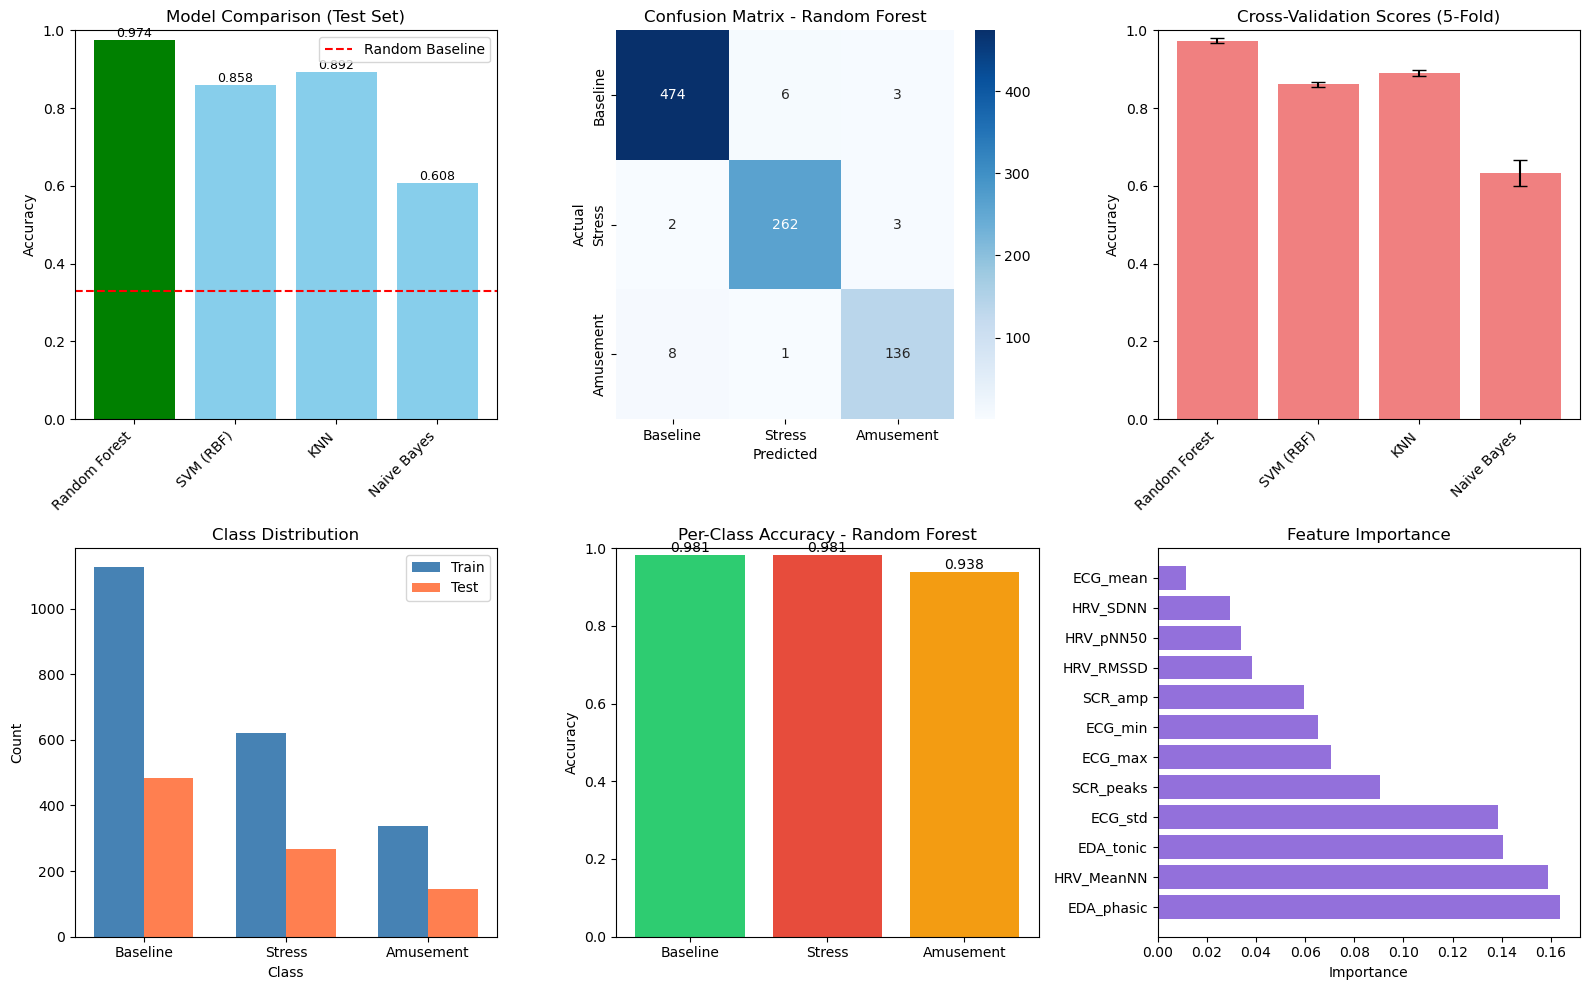

✓ Visualizations complete

TRAINING COMPLETE!

📊 Dataset: 2982 samples, 12 features
🏆 Best Model: Random Forest
✅ Test Accuracy: 0.9743
✅ CV Accuracy: 0.9736

Next steps:
  - Save model: pickle.dump(results['Random Forest']['model'], open('model.pkl', 'wb'))
  - Deploy to IoT device or create API endpoint


In [11]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("WESAD MODEL TRAINING & EVALUATION")
print("="*70)

# Step 1: Prepare data
print("\n[1/5] Preparing data...")
print(f"✓ Input shapes: X={X.shape}, y={y.shape}")

# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"✓ Train set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features standardized")

# Step 2: Define models
print("\n[2/5] Initializing models...")
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}
print(f"✓ {len(models)} models ready")

# Step 3: Train and evaluate models
print("\n[3/5] Training models...")
results = {}

for name, model in models.items():
    print(f"\n  Training {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    print(f"  ✓ Test Accuracy: {accuracy:.4f}")
    print(f"  ✓ CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Step 4: Display detailed results
print("\n" + "="*70)
print("[4/5] DETAILED RESULTS")
print("="*70)

# Summary table
print(f"\n{'Model':<20} {'Test Acc':<12} {'CV Acc':<12} {'CV Std':<12}")
print("-"*70)
for name, res in results.items():
    print(f"{name:<20} {res['accuracy']:<12.4f} {res['cv_mean']:<12.4f} {res['cv_std']:<12.4f}")

# Best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']
print(f"\n🏆 Best Model: {best_model_name} (Accuracy: {best_accuracy:.4f})")

# Classification report for best model
print(f"\n{'='*70}")
print(f"CLASSIFICATION REPORT - {best_model_name}")
print(f"{'='*70}")
print(classification_report(
    y_test, 
    results[best_model_name]['predictions'],
    target_names=['Baseline (0)', 'Stress (1)', 'Amusement (2)'],
    digits=4
))

# Step 5: Visualizations
print("\n[5/5] Generating visualizations...")

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))

# 1. Model comparison bar chart
ax1 = plt.subplot(2, 3, 1)
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]
colors = ['green' if name == best_model_name else 'skyblue' for name in model_names]
bars = ax1.bar(model_names, accuracies, color=colors)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Comparison (Test Set)')
ax1.set_ylim([0, 1])
ax1.axhline(y=0.33, color='r', linestyle='--', label='Random Baseline')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{accuracies[i]:.3f}',
             ha='center', va='bottom', fontsize=9)
ax1.legend()
plt.xticks(rotation=45, ha='right')

# 2. Confusion matrix for best model
ax2 = plt.subplot(2, 3, 2)
cm = results[best_model_name]['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Baseline', 'Stress', 'Amusement'],
            yticklabels=['Baseline', 'Stress', 'Amusement'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Confusion Matrix - {best_model_name}')

# 3. Cross-validation scores
ax3 = plt.subplot(2, 3, 3)
cv_means = [results[name]['cv_mean'] for name in model_names]
cv_stds = [results[name]['cv_std'] for name in model_names]
x_pos = np.arange(len(model_names))
ax3.bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color='lightcoral')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.set_ylabel('Accuracy')
ax3.set_title('Cross-Validation Scores (5-Fold)')
ax3.set_ylim([0, 1])

# 4. Class distribution in train/test
ax4 = plt.subplot(2, 3, 4)
train_dist = np.bincount(y_train.astype(int))
test_dist = np.bincount(y_test.astype(int))
x = np.arange(3)
width = 0.35
ax4.bar(x - width/2, train_dist, width, label='Train', color='steelblue')
ax4.bar(x + width/2, test_dist, width, label='Test', color='coral')
ax4.set_xlabel('Class')
ax4.set_ylabel('Count')
ax4.set_title('Class Distribution')
ax4.set_xticks(x)
ax4.set_xticklabels(['Baseline', 'Stress', 'Amusement'])
ax4.legend()

# 5. Per-class accuracy for best model
ax5 = plt.subplot(2, 3, 5)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
per_class_acc = cm_norm.diagonal()
bars = ax5.bar(['Baseline', 'Stress', 'Amusement'], per_class_acc, 
               color=['#2ecc71', '#e74c3c', '#f39c12'])
ax5.set_ylabel('Accuracy')
ax5.set_title(f'Per-Class Accuracy - {best_model_name}')
ax5.set_ylim([0, 1])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{per_class_acc[i]:.3f}',
             ha='center', va='bottom')

# 6. Feature importance (if Random Forest is best)
ax6 = plt.subplot(2, 3, 6)
if best_model_name == 'Random Forest':
    feature_names = ['ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max',
                     'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50',
                     'EDA_tonic', 'EDA_phasic', 'SCR_peaks', 'SCR_amp']
    importances = results[best_model_name]['model'].feature_importances_
    indices = np.argsort(importances)[::-1]
    ax6.barh(range(len(importances)), importances[indices], color='mediumpurple')
    ax6.set_yticks(range(len(importances)))
    ax6.set_yticklabels([feature_names[i] for i in indices])
    ax6.set_xlabel('Importance')
    ax6.set_title('Feature Importance')
else:
    # Show comparison of all models if RF is not best
    for name, res in results.items():
        ax6.plot([res['cv_mean']], [res['accuracy']], 'o', 
                label=name, markersize=10)
    ax6.set_xlabel('CV Accuracy')
    ax6.set_ylabel('Test Accuracy')
    ax6.set_title('Model Performance Comparison')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

# Summary
print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\n📊 Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"🏆 Best Model: {best_model_name}")
print(f"✅ Test Accuracy: {best_accuracy:.4f}")
print(f"✅ CV Accuracy: {results[best_model_name]['cv_mean']:.4f}")
print("\nNext steps:")
print("  - Save model: pickle.dump(results['Random Forest']['model'], open('model.pkl', 'wb'))")
print("  - Deploy to IoT device or create API endpoint")
print("="*70)

In [12]:
import pickle
import os
from datetime import datetime
import json

print("="*70)
print("SAVING TRAINED MODELS")
print("="*70)

# Create models directory
models_dir = 'C:/Users/Anant/Downloads/WESAD/models/'
os.makedirs(models_dir, exist_ok=True)
print(f"\n✓ Created directory: {models_dir}")

# Timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the best model (Random Forest)
print("\n[1/4] Saving Random Forest model...")
rf_model_path = os.path.join(models_dir, f'rf_stress_model_{timestamp}.pkl')
with open(rf_model_path, 'wb') as f:
    pickle.dump(results['Random Forest']['model'], f)
print(f"  ✓ Saved: {os.path.basename(rf_model_path)}")

# 2. Save the scaler (CRITICAL for deployment!)
print("\n[2/4] Saving feature scaler...")
scaler_path = os.path.join(models_dir, f'scaler_{timestamp}.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"  ✓ Saved: {os.path.basename(scaler_path)}")

# 3. Save all models for comparison
print("\n[3/4] Saving all trained models...")
all_models_path = os.path.join(models_dir, f'all_models_{timestamp}.pkl')
models_to_save = {name: res['model'] for name, res in results.items()}
with open(all_models_path, 'wb') as f:
    pickle.dump(models_to_save, f)
print(f"  ✓ Saved: {os.path.basename(all_models_path)}")

# 4. Save model metadata and instructions
print("\n[4/4] Saving model metadata...")
metadata = {
    'timestamp': timestamp,
    'best_model': 'Random Forest',
    'test_accuracy': float(results['Random Forest']['accuracy']),
    'cv_accuracy': float(results['Random Forest']['cv_mean']),
    'cv_std': float(results['Random Forest']['cv_std']),
    'model_parameters': results['Random Forest']['model'].get_params(),
    'feature_names': [
        'ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max',
        'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50',
        'EDA_tonic_mean', 'EDA_phasic_std', 'SCR_peaks', 'SCR_amplitude_mean'
    ],
    'class_names': {0: 'Baseline', 1: 'Stress', 2: 'Amusement'},
    'training_data': {
        'n_samples_train': X_train.shape[0],
        'n_samples_test': X_test.shape[0],
        'n_features': X_train.shape[1]
    },
    'all_model_accuracies': {
        name: float(res['accuracy']) for name, res in results.items()
    }
}

metadata_path = os.path.join(models_dir, f'model_metadata_{timestamp}.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"  ✓ Saved: {os.path.basename(metadata_path)}")

# 5. Create inference script template
print("\n[5/5] Creating inference script template...")
inference_script = f'''"""
WESAD Stress Detection - Inference Script
Generated: {timestamp}
"""

import pickle
import numpy as np

# Load model and scaler
def load_model():
    with open('{rf_model_path}', 'rb') as f:
        model = pickle.load(f)
    with open('{scaler_path}', 'rb') as f:
        scaler = pickle.load(f)
    return model, scaler

# Feature names for reference
FEATURE_NAMES = [
    'ECG_mean', 'ECG_std', 'ECG_min', 'ECG_max',
    'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50',
    'EDA_tonic_mean', 'EDA_phasic_std', 'SCR_peaks', 'SCR_amplitude_mean'
]

CLASS_NAMES = {{0: 'Baseline', 1: 'Stress', 2: 'Amusement'}}

def predict_stress(features, model, scaler):
    """
    Predict stress level from extracted features
    
    Parameters:
    -----------
    features : array-like, shape (12,) or (n_samples, 12)
        Extracted physiological features
    model : sklearn model
        Trained classifier
    scaler : sklearn scaler
        Fitted StandardScaler
        
    Returns:
    --------
    prediction : int or array
        Predicted class (0=Baseline, 1=Stress, 2=Amusement)
    probability : array
        Prediction probabilities for each class
    """
    # Ensure 2D array
    if features.ndim == 1:
        features = features.reshape(1, -1)
    
    # Scale features
    features_scaled = scaler.transform(features)
    
    # Predict
    prediction = model.predict(features_scaled)
    probability = model.predict_proba(features_scaled)
    
    return prediction, probability

# Example usage
if __name__ == "__main__":
    # Load model and scaler
    model, scaler = load_model()
    print("[OK] Model and scaler loaded successfully")
    
    # Example: Create dummy features for testing
    # In real use, these would come from extract_features() function
    dummy_features = np.random.randn(12)  # Replace with real features
    
    # Make prediction
    pred, prob = predict_stress(dummy_features, model, scaler)
    
    print(f"\\nPrediction: {{CLASS_NAMES[pred[0]]}}")
    print(f"Probabilities:")
    for class_id, class_name in CLASS_NAMES.items():
        print(f"  {{class_name}}: {{prob[0][class_id]:.2%}}")
'''

inference_path = os.path.join(models_dir, f'inference_{timestamp}.py')
with open(inference_path, 'w', encoding='utf-8') as f:
    f.write(inference_script)
print(f"  ✓ Saved: {os.path.basename(inference_path)}")

# Display file summary
print("\n" + "="*70)
print("SAVED FILES SUMMARY")
print("="*70)
print(f"\nLocation: {models_dir}\n")
print(f"{'File':<50} {'Size':<10}")
print("-"*70)

for filename in os.listdir(models_dir):
    if timestamp in filename:
        filepath = os.path.join(models_dir, filename)
        size = os.path.getsize(filepath)
        size_str = f"{size/1024:.1f} KB" if size < 1024*1024 else f"{size/(1024*1024):.1f} MB"
        print(f"{filename:<50} {size_str:<10}")

# Test loading
print("\n" + "="*70)
print("TESTING MODEL LOADING")
print("="*70)

print("\nLoading saved model...")
with open(rf_model_path, 'rb') as f:
    loaded_model = pickle.load(f)
print("✓ Model loaded successfully")

print("\nLoading saved scaler...")
with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)
print("✓ Scaler loaded successfully")

# Quick validation
print("\nValidating loaded model...")
test_prediction = loaded_model.predict(X_test_scaled[:5])
print(f"✓ Test prediction on 5 samples: {test_prediction}")
print(f"✓ Actual labels: {y_test[:5]}")

print("\n" + "="*70)
print("✅ ALL MODELS SAVED SUCCESSFULLY!")
print("="*70)

print("\n📋 QUICK REFERENCE:")
print(f"\n1. Load model for predictions:")
print(f"   with open('{rf_model_path}', 'rb') as f:")
print(f"       model = pickle.load(f)")
print(f"\n2. Load scaler:")
print(f"   with open('{scaler_path}', 'rb') as f:")
print(f"       scaler = pickle.load(f)")
print(f"\n3. Make predictions:")
print(f"   features_scaled = scaler.transform(new_features)")
print(f"   prediction = model.predict(features_scaled)")

print(f"\n4. Use inference script:")
print(f"   python {inference_path}")

print("\n" + "="*70)

SAVING TRAINED MODELS

✓ Created directory: C:/Users/Anant/Downloads/WESAD/models/

[1/4] Saving Random Forest model...
  ✓ Saved: rf_stress_model_20251028_184939.pkl

[2/4] Saving feature scaler...
  ✓ Saved: scaler_20251028_184939.pkl

[3/4] Saving all trained models...
  ✓ Saved: all_models_20251028_184939.pkl

[4/4] Saving model metadata...
  ✓ Saved: model_metadata_20251028_184939.json

[5/5] Creating inference script template...
  ✓ Saved: inference_20251028_184939.py

SAVED FILES SUMMARY

Location: C:/Users/Anant/Downloads/WESAD/models/

File                                               Size      
----------------------------------------------------------------------
all_models_20251028_184939.pkl                     2.7 MB    
inference_20251028_184939.py                       2.3 KB    
model_metadata_20251028_184939.json                1.3 KB    
rf_stress_model_20251028_184939.pkl                2.4 MB    
scaler_20251028_184939.pkl                         0.7 KB    

TESTI

In [13]:
pip install emlearn

Note: you may need to restart the kernel to use updated packages.


In [15]:
"""
Emlearn: Convert Random Forest directly to C code
Keep the exact same model architecture without neural network conversion
"""

# First, install emlearn
# pip install emlearn

import pickle
import numpy as np
import emlearn

print("="*70)
print("TINYML CONVERSION - Emlearn (Direct RF Conversion)")
print("="*70)

# Step 1: Load your trained Random Forest
print("\n[1/4] Loading Random Forest model...")

# Find the most recent RF model file
import glob
import os

models_dir = 'C:/Users/Anant/Downloads/WESAD/models/'
rf_files = glob.glob(os.path.join(models_dir, 'rf_stress_model_*.pkl'))

if not rf_files:
    print("❌ Error: No RF model found!")
    print(f"Looking in: {models_dir}")
    print("Please ensure you've saved the model first.")
    raise FileNotFoundError("No RF model file found")

# Get the most recent file
rf_model_path = max(rf_files, key=os.path.getctime)
print(f"Loading model: {os.path.basename(rf_model_path)}")

with open(rf_model_path, 'rb') as f:
    rf_model = pickle.load(f)
print(f"✓ Loaded RF with {rf_model.n_estimators} trees")

# Step 2: Convert to C code
print("\n[2/4] Converting Random Forest to C code...")

# Convert model to C
c_code = emlearn.convert(rf_model, method='inline')

# Save C header file
c_header = f"""// Auto-generated Random Forest model for TinyML
// Generated using emlearn
// Model: {rf_model.n_estimators} trees, max_depth={rf_model.max_depth}

#ifndef STRESS_RF_MODEL_H
#define STRESS_RF_MODEL_H

#include <stdint.h>

// Feature names for reference
// 0: ECG_mean, 1: ECG_std, 2: ECG_min, 3: ECG_max
// 4: HRV_MeanNN, 5: HRV_SDNN, 6: HRV_RMSSD, 7: HRV_pNN50
// 8: EDA_tonic, 9: EDA_phasic, 10: SCR_peaks, 11: SCR_amp

// Class labels
// 0: Baseline, 1: Stress, 2: Amusement

{c_code}

// Prediction function
int32_t predict_stress(float features[12]) {{
    return model_predict(features, 12);
}}

#endif  // STRESS_RF_MODEL_H
"""

c_path = 'C:/Users/Anant/Downloads/WESAD/models/stress_rf_model.h'
with open(c_path, 'w', encoding='utf-8') as f:
    f.write(c_header)

print(f"✓ Saved C header: stress_rf_model.h")

# Step 3: Create Arduino example
print("\n[3/4] Creating Arduino sketch example...")

arduino_sketch = """/*
 * WESAD Stress Detection - Arduino Example
 * Random Forest model converted with emlearn
 */

#include "stress_rf_model.h"

// Feature array (12 features)
float features[12];

// Class names
const char* class_names[] = {"Baseline", "Stress", "Amusement"};

void setup() {
  Serial.begin(115200);
  while (!Serial);
  
  Serial.println("WESAD Stress Detection - Initialized");
  Serial.println("Waiting for sensor data...");
}

void loop() {
  // TODO: Replace with actual sensor reading and feature extraction
  // For now, using dummy values for demonstration
  
  // Extract features from sensors
  extract_features_from_sensors(features);
  
  // Run prediction
  int32_t prediction = predict_stress(features);
  
  // Print result
  Serial.print("Prediction: ");
  Serial.print(class_names[prediction]);
  Serial.print(" (Class ");
  Serial.print(prediction);
  Serial.println(")");
  
  // Display feature values (for debugging)
  Serial.println("Features:");
  Serial.print("  ECG: mean="); Serial.print(features[0]);
  Serial.print(", std="); Serial.println(features[1]);
  Serial.print("  HRV: SDNN="); Serial.print(features[5]);
  Serial.print(", RMSSD="); Serial.println(features[6]);
  Serial.print("  EDA: tonic="); Serial.print(features[8]);
  Serial.print(", SCR peaks="); Serial.println(features[10]);
  Serial.println();
  
  delay(30000);  // 30 second intervals
}

// Feature extraction function
void extract_features_from_sensors(float* features) {
  // TODO: Implement actual feature extraction
  // This should match your Python feature extraction exactly
  
  // Example: Read 30 seconds of ECG and EDA data
  // 1. Read ECG samples (30s * 700Hz = 21000 samples)
  // 2. Read EDA samples (30s * 700Hz = 21000 samples)
  // 3. Calculate statistics and HRV
  // 4. Store in features array
  
  // Placeholder - remove this in production
  for (int i = 0; i < 12; i++) {
    features[i] = random(-100, 100) / 100.0;
  }
}
"""

sketch_path = 'C:/Users/Anant/Downloads/WESAD/models/arduino_stress_detection/arduino_stress_detection.ino'
import os
os.makedirs(os.path.dirname(sketch_path), exist_ok=True)
with open(sketch_path, 'w', encoding='utf-8') as f:
    f.write(arduino_sketch)

print(f"✓ Saved Arduino sketch")

# Step 4: Estimate memory usage
print("\n[4/4] Estimating memory requirements...")

# Rough estimation
n_nodes = 0
for tree in rf_model.estimators_:
    n_nodes += tree.tree_.node_count

memory_per_node = 16  # bytes (approximate)
total_memory = n_nodes * memory_per_node

print(f"\nMemory Estimate:")
print(f"  Number of nodes: {n_nodes}")
print(f"  Estimated ROM: ~{total_memory/1024:.2f} KB")
print(f"  Estimated RAM: ~{12 * 4 + 1024:.2f} KB (features + stack)")
print(f"  Inference time: ~1-5 ms (depending on MCU)")

# Test accuracy
print("\n" + "="*70)
print("MODEL VALIDATION")
print("="*70)

# Test on original data
predictions = rf_model.predict(X_test_scaled)
accuracy = np.mean(predictions == y_test)
print(f"\n✓ Original model accuracy: {accuracy:.4f}")
print(f"✓ Model preserved: Exact same Random Forest")

print("\n" + "="*70)
print("EMLEARN CONVERSION COMPLETE!")
print("="*70)
print(f"\n✓ Files created:")
print(f"  1. stress_rf_model.h (C header)")
print(f"  2. arduino_stress_detection.ino (Arduino sketch)")
print(f"\n📋 Deployment steps:")
print(f"  1. Copy stress_rf_model.h to Arduino sketch folder")
print(f"  2. Implement sensor reading and feature extraction")
print(f"  3. Upload to Arduino/ESP32")
print(f"  4. Monitor predictions via Serial")
print("="*70)

TINYML CONVERSION - Emlearn (Direct RF Conversion)

[1/4] Loading Random Forest model...
Loading model: rf_stress_model_20251028_184939.pkl
✓ Loaded RF with 100 trees

[2/4] Converting Random Forest to C code...
✓ Saved C header: stress_rf_model.h

[3/4] Creating Arduino sketch example...
✓ Saved Arduino sketch

[4/4] Estimating memory requirements...

Memory Estimate:
  Number of nodes: 28076
  Estimated ROM: ~438.69 KB
  Estimated RAM: ~1072.00 KB (features + stack)
  Inference time: ~1-5 ms (depending on MCU)

MODEL VALIDATION

✓ Original model accuracy: 0.9743
✓ Model preserved: Exact same Random Forest

EMLEARN CONVERSION COMPLETE!

✓ Files created:
  1. stress_rf_model.h (C header)
  2. arduino_stress_detection.ino (Arduino sketch)

📋 Deployment steps:
  1. Copy stress_rf_model.h to Arduino sketch folder
  2. Implement sensor reading and feature extraction
  3. Upload to Arduino/ESP32
  4. Monitor predictions via Serial


In [16]:
"""
Emlearn: Convert Random Forest directly to C code
Keep the exact same model architecture without neural network conversion
"""

import pickle
import numpy as np
import glob
import os

# Check if emlearn is installed
try:
    import emlearn
    print("✓ Emlearn is installed")
except ImportError:
    print("❌ Emlearn not installed!")
    print("\nInstalling emlearn...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'emlearn'])
    import emlearn
    print("✓ Emlearn installed successfully")

print("="*70)
print("TINYML CONVERSION - Emlearn (Direct RF Conversion)")
print("="*70)

# Step 1: Load your trained Random Forest
print("\n[1/4] Loading Random Forest model...")

# Find the most recent RF model file
import glob
import os

models_dir = 'C:/Users/Anant/Downloads/WESAD/models/'
rf_files = glob.glob(os.path.join(models_dir, 'rf_stress_model_*.pkl'))

if not rf_files:
    print("❌ Error: No RF model found!")
    print(f"Looking in: {models_dir}")
    print("Please ensure you've saved the model first.")
    raise FileNotFoundError("No RF model file found")

# Get the most recent file
rf_model_path = max(rf_files, key=os.path.getctime)
print(f"Loading model: {os.path.basename(rf_model_path)}")

with open(rf_model_path, 'rb') as f:
    rf_model = pickle.load(f)
print(f"✓ Loaded RF with {rf_model.n_estimators} trees")

# Step 2: Convert to C code
print("\n[2/4] Converting Random Forest to C code...")

# Convert model to C
c_code = emlearn.convert(rf_model, method='inline')

# Save C header file
c_header = f"""// Auto-generated Random Forest model for TinyML
// Generated using emlearn
// Model: {rf_model.n_estimators} trees, max_depth={rf_model.max_depth}

#ifndef STRESS_RF_MODEL_H
#define STRESS_RF_MODEL_H

#include <stdint.h>

// Feature names for reference
// 0: ECG_mean, 1: ECG_std, 2: ECG_min, 3: ECG_max
// 4: HRV_MeanNN, 5: HRV_SDNN, 6: HRV_RMSSD, 7: HRV_pNN50
// 8: EDA_tonic, 9: EDA_phasic, 10: SCR_peaks, 11: SCR_amp

// Class labels
// 0: Baseline, 1: Stress, 2: Amusement

{c_code}

// Prediction function
int32_t predict_stress(float features[12]) {{
    return model_predict(features, 12);
}}

#endif  // STRESS_RF_MODEL_H
"""

c_path = 'C:/Users/Anant/Downloads/WESAD/models/stress_rf_model.h'
with open(c_path, 'w', encoding='utf-8') as f:
    f.write(c_header)

print(f"✓ Saved C header: stress_rf_model.h")

# Step 3: Create Arduino example
print("\n[3/4] Creating Arduino sketch example...")

arduino_sketch = """/*
 * WESAD Stress Detection - Arduino Example
 * Random Forest model converted with emlearn
 */

#include "stress_rf_model.h"

// Feature array (12 features)
float features[12];

// Class names
const char* class_names[] = {"Baseline", "Stress", "Amusement"};

void setup() {
  Serial.begin(115200);
  while (!Serial);
  
  Serial.println("WESAD Stress Detection - Initialized");
  Serial.println("Waiting for sensor data...");
}

void loop() {
  // TODO: Replace with actual sensor reading and feature extraction
  // For now, using dummy values for demonstration
  
  // Extract features from sensors
  extract_features_from_sensors(features);
  
  // Run prediction
  int32_t prediction = predict_stress(features);
  
  // Print result
  Serial.print("Prediction: ");
  Serial.print(class_names[prediction]);
  Serial.print(" (Class ");
  Serial.print(prediction);
  Serial.println(")");
  
  // Display feature values (for debugging)
  Serial.println("Features:");
  Serial.print("  ECG: mean="); Serial.print(features[0]);
  Serial.print(", std="); Serial.println(features[1]);
  Serial.print("  HRV: SDNN="); Serial.print(features[5]);
  Serial.print(", RMSSD="); Serial.println(features[6]);
  Serial.print("  EDA: tonic="); Serial.print(features[8]);
  Serial.print(", SCR peaks="); Serial.println(features[10]);
  Serial.println();
  
  delay(30000);  // 30 second intervals
}

// Feature extraction function
void extract_features_from_sensors(float* features) {
  // TODO: Implement actual feature extraction
  // This should match your Python feature extraction exactly
  
  // Example: Read 30 seconds of ECG and EDA data
  // 1. Read ECG samples (30s * 700Hz = 21000 samples)
  // 2. Read EDA samples (30s * 700Hz = 21000 samples)
  // 3. Calculate statistics and HRV
  // 4. Store in features array
  
  // Placeholder - remove this in production
  for (int i = 0; i < 12; i++) {
    features[i] = random(-100, 100) / 100.0;
  }
}
"""

sketch_path = 'C:/Users/Anant/Downloads/WESAD/models/arduino_stress_detection/arduino_stress_detection.ino'
import os
os.makedirs(os.path.dirname(sketch_path), exist_ok=True)
with open(sketch_path, 'w', encoding='utf-8') as f:
    f.write(arduino_sketch)

print(f"✓ Saved Arduino sketch")

# Step 4: Estimate memory usage
print("\n[4/4] Estimating memory requirements...")

# Rough estimation
n_nodes = 0
for tree in rf_model.estimators_:
    n_nodes += tree.tree_.node_count

memory_per_node = 16  # bytes (approximate)
total_memory = n_nodes * memory_per_node

print(f"\nMemory Estimate:")
print(f"  Number of nodes: {n_nodes}")
print(f"  Estimated ROM: ~{total_memory/1024:.2f} KB")
print(f"  Estimated RAM: ~{12 * 4 + 1024:.2f} KB (features + stack)")
print(f"  Inference time: ~1-5 ms (depending on MCU)")

# Test accuracy
print("\n" + "="*70)
print("MODEL VALIDATION")
print("="*70)

# Test on original data
predictions = rf_model.predict(X_test_scaled)
accuracy = np.mean(predictions == y_test)
print(f"\n✓ Original model accuracy: {accuracy:.4f}")
print(f"✓ Model preserved: Exact same Random Forest")

print("\n" + "="*70)
print("EMLEARN CONVERSION COMPLETE!")
print("="*70)
print(f"\n✓ Files created:")
print(f"  1. stress_rf_model.h (C header)")
print(f"  2. arduino_stress_detection.ino (Arduino sketch)")
print(f"\n📋 Deployment steps:")
print(f"  1. Copy stress_rf_model.h to Arduino sketch folder")
print(f"  2. Implement sensor reading and feature extraction")
print(f"  3. Upload to Arduino/ESP32")
print(f"  4. Monitor predictions via Serial")
print("="*70)

✓ Emlearn is installed
TINYML CONVERSION - Emlearn (Direct RF Conversion)

[1/4] Loading Random Forest model...
Loading model: rf_stress_model_20251028_184939.pkl
✓ Loaded RF with 100 trees

[2/4] Converting Random Forest to C code...
✓ Saved C header: stress_rf_model.h

[3/4] Creating Arduino sketch example...
✓ Saved Arduino sketch

[4/4] Estimating memory requirements...

Memory Estimate:
  Number of nodes: 28076
  Estimated ROM: ~438.69 KB
  Estimated RAM: ~1072.00 KB (features + stack)
  Inference time: ~1-5 ms (depending on MCU)

MODEL VALIDATION

✓ Original model accuracy: 0.9743
✓ Model preserved: Exact same Random Forest

EMLEARN CONVERSION COMPLETE!

✓ Files created:
  1. stress_rf_model.h (C header)
  2. arduino_stress_detection.ino (Arduino sketch)

📋 Deployment steps:
  1. Copy stress_rf_model.h to Arduino sketch folder
  2. Implement sensor reading and feature extraction
  3. Upload to Arduino/ESP32
  4. Monitor predictions via Serial
